In [91]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
insurance=pd.read_csv(r"C:\Users\myjyu\Downloads\insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [92]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [93]:
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [94]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [95]:
insurance.duplicated().sum()

np.int64(1)

In [96]:
smoker_value={'yes':1,'no':0}
insurance['smoker_numeric']=insurance['smoker'].map(smoker_value)
insurance

,age,sex,bmi,children,smoker,region,charges,smoker_numeric
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


Age Distribution

In [97]:
fig=px.histogram(insurance,x='age', marginal='box',nbins=47,title='Age Distribution')
fig.update_layout(bargap=0.1)
fig

BMI Distribution

In [98]:
fig=px.histogram(insurance,x='bmi',marginal='box',nbins=47,title='BMI Distribution')
fig.update_layout(bargap=0.1)
fig

Charges Distribution

In [99]:
fig=px.histogram(insurance,x='charges',marginal='box',title='Charges Distribution',color='smoker',color_discrete_map={'yes':'red','no':'blue'})
fig.update_layout(bargap=0.1)
fig

Sex Distribution

In [100]:
fig=px.histogram(insurance,x='sex',marginal='box',title='Sex Distribution',color="smoker",color_discrete_map={'yes':'red','no':'blue'})
fig.update_layout(bargap=0.1)
fig

Age vs Charges

In [101]:
fig=px.scatter(insurance,x='age',y='charges',color='smoker',color_discrete_map={'yes':'red','no':'blue'},title='Age vs Charges')
fig

BMI vs Charges

In [102]:
fig=px.scatter(insurance,x='bmi',y='charges',marginal_x='box',color='smoker',color_discrete_map={'yes':'red','no':'blue'},title='BMI vs Charges')
fig

In [103]:
insurance.corr(numeric_only=True)
model=LinearRegression()

Non-smoker_charges_prediction


In [104]:
non_smoker=insurance[insurance['smoker']=="no"]
input1=non_smoker[['age']]
targets1=non_smoker['charges']  
model.fit(input1,targets1)
x_train,x_test,y_train,y_test=train_test_split(input1,targets1,test_size=0.2,random_state=42)
model.fit(x_train,y_train)
non_smoker_charge_predction=model.predict(x_test)
ages=non_smoker.age

Graph For Non-smoker_charges_prediction


<Axes: title={'center': 'age vs charges for non-smokers'}, xlabel='age', ylabel='charges'>

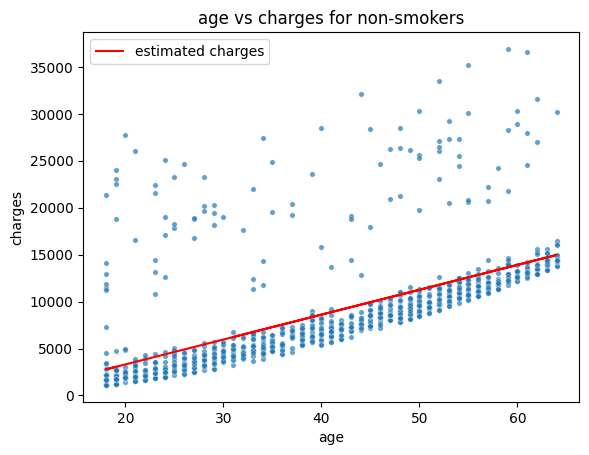

In [105]:
plt.title('age vs charges for non-smokers')
plt.plot(x_test,non_smoker_charge_predction,color='red',label='estimated charges')
sns.scatterplot(data=non_smoker,x='age',y='charges',alpha=0.7,s=15)

Non Smoker Charge Model Evaluation

In [106]:
print("R2 Score:", r2_score(y_test,non_smoker_charge_predction))
print("MAE:", mean_absolute_error(y_test, non_smoker_charge_predction))
print("MSE:", mean_squared_error(y_test, non_smoker_charge_predction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, non_smoker_charge_predction)))

R2 Score: 0.441641810147521
MAE: 2508.682862791196
MSE: 19603075.14431584
RMSE: 4427.536012763288


External Input For NON Smoker Charge Prediction

In [107]:
age=int(input("Enter the age of the non-smoker: "))
non_smoker_charge_prediction=model.predict([[age]])
print('NON Smoker Charges Prediction:',non_smoker_charge_prediction[0])

NON Smoker Charges Prediction: 3040.208588915125


c:\Users\myjyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


smokers_charge_prediction

In [108]:
smokers = insurance[insurance['smoker'] == "yes"]
input2=smokers[['age']]
targets2=smokers['charges']
model.fit(input2,targets2)
x_train,x_test,y_train,y_test=train_test_split(input2,targets2,test_size=0.2,random_state=42)
model.fit(x_train,y_train)
age2=smokers.age
smoker_charge_prediction=model.predict(x_test)

Graph For Smoker Charge Prediction

<Axes: title={'center': 'age vs charges for smokers'}, xlabel='age', ylabel='charges'>

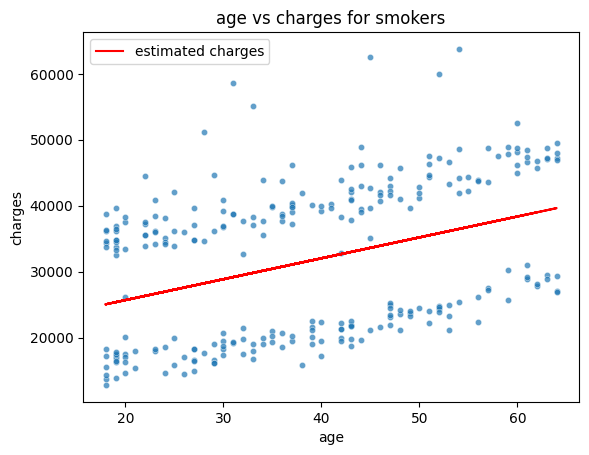

In [109]:
plt.title('age vs charges for smokers')
plt.plot(x_test,smoker_charge_prediction,color='red',label='estimated charges')
sns.scatterplot(data=smokers,x='age',y='charges',alpha=0.7,s=20)

Smoker Charge Model Evaluation

In [110]:
print("R2 Score:", r2_score(y_test,smoker_charge_prediction))
print("MAE:", mean_absolute_error(y_test, smoker_charge_prediction))
print("MSE:", mean_squared_error(y_test, smoker_charge_prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, smoker_charge_prediction)))

R2 Score: 0.06509862806261313
MAE: 11068.729655335135
MSE: 140278327.00197324
RMSE: 11843.915188904944


External Input For  Smoker Charge Prediction

In [111]:
age=int(input("Enter the age of the smoker: "))
smoker_charge_prediction=model.predict([[age]])
print('Smoker Charges Prediction:',smoker_charge_prediction[0])

Smoker Charges Prediction: 25370.44116619892


c:\Users\myjyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
